# Circuits for Lesson 2 of the Tutorial

The 6 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 2 of the Tutorial*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. AS5's Figure 2.29

The first purely symbolic problem: find expressions for the current i, the voltage drop across r2, the power consumed by r2 and the power delivered by the source. Symbolic all through: every answer is a formula — the voltage divider you would have written by hand.

![The circuit of AS5's Figure 2.29](https://learn.symbulator.com/assets/circuit/as5f0229.png)

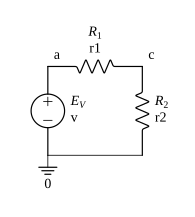

In [3]:
c1 = '''
ev,a,0,v
r1,a,c,r1
r2,c,0,r2
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1

Result(domain='dc')
  i_ev = -v/(r1 + r2)
  i_r1 = v/(r1 + r2)
  i_r2 = v/(r1 + r2)
  p_ev = -v**2/(r1 + r2)
  p_r1 = r1*v**2/(r1 + r2)**2
  p_r2 = r2*v**2/(r1 + r2)**2
  r_ev = r1 + r2
  v_a = v
  v_c = r2*v/(r1 + r2)
  v_ev = v
  v_r1 = r1*v/(r1 + r2)
  v_r2 = r2*v/(r1 + r2)

In [5]:
evaluate(r1, '-pev')

v**2/(r1 + r2)

## 2. B11's Example 5.6 (with the Solve equations card)

A numerical-from-symbolic problem: the source E and the resistor R1 are unknown, but the problem says the source sees 12 kohm and that I3 is 6 mA. Find E and R1. Solve the circuit first, then use the Solve equations card.

![The circuit of B11's Example 5.6 (with the Solve equations card)](https://learn.symbulator.com/assets/circuit/b11e0506.jpg)

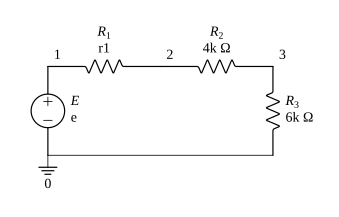

In [6]:
c2 = '''
e,1,0,e
r1,1,2,r1
r2,2,3,4'k
r3,3,0,6'k
'''
draw(c2)

In [7]:
r2 = dc(c2)
r2

Result(domain='dc')
  i_e = -e/(r1 + 10000)
  i_r1 = e/(r1 + 10000)
  i_r2 = e/(r1 + 10000)
  i_r3 = e/(r1 + 10000)
  p_e = -e**2/(r1 + 10000)
  p_r1 = e**2*r1/(r1 + 10000)**2
  p_r2 = 4000*e**2/(r1 + 10000)**2
  p_r3 = 6000*e**2/(r1 + 10000)**2
  r_e = r1 + 10000
  v_1 = e
  v_2 = 10000*e/(r1 + 10000)
  v_3 = 6000*e/(r1 + 10000)
  v_e = e
  v_r1 = e*r1/(r1 + 10000)
  v_r2 = 4000*e/(r1 + 10000)
  v_r3 = 6000*e/(r1 + 10000)

In [8]:
solve(r2, ["re = 12'k", "ir3 = 6'm"], ['e', 'r1'])

[{'e': 72, 'r1': 2000}]

## 3. B11's Example 5.6 (using Expert Mode)

In this problem, we use Expert Mode for the first time: the same problem as the previous entry, with the two facts handed over before solving, so the whole circuit comes back numerical.

![The circuit of B11's Example 5.6 (using Expert Mode)](https://learn.symbulator.com/assets/circuit/b11e0506.jpg)

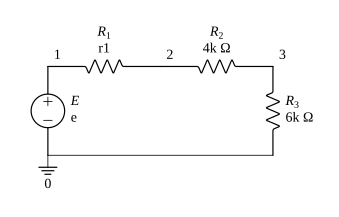

In [9]:
c3 = '''
e,1,0,e
r1,1,2,r1
r2,2,3,4'k
r3,3,0,6'k
'''
draw(c3)

In [10]:
r3 = dc(c3, equations=["r_e = 12'k", "i_r3 = 6'm"], unknowns=['e', 'r1'])
r3

Result(domain='dc')
  e = 72
  i_e = -3/500
  i_r1 = 3/500
  i_r2 = 3/500
  i_r3 = 3/500
  p_e = -54/125
  p_r1 = 9/125
  p_r2 = 18/125
  p_r3 = 27/125
  r1 = 2000
  r_e = 12000
  v_1 = 72
  v_2 = 60
  v_3 = 36
  v_e = 72
  v_r1 = 12
  v_r2 = 24
  v_r3 = 36

## 4. HK5's Figure 1-24a

Find ix and vx. ra is never needed: the circuit's structure answers both questions without it.

![The circuit of HK5's Figure 1-24a](https://learn.symbulator.com/assets/practice/hk5s-figure-1-24a-solve-1.jpg)

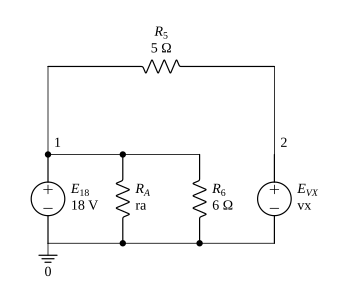

In [11]:
c4 = '''
e18,1,0,18
ra,1,0,ra
r6,1,0,6
r5,2,1,5
evx,2,0,vx
'''
draw(c4)

In [12]:
r4 = dc(c4)
r4

Result(domain='dc')
  i_e18 = vx/5 - 33/5 - 18/ra
  i_evx = 18/5 - vx/5
  i_r5 = vx/5 - 18/5
  i_r6 = 3
  i_ra = 18/ra
  p_e18 = 18*(ra*(vx - 33) - 90)/(5*ra)
  p_evx = vx*(18 - vx)/5
  p_r5 = (vx - 18)**2/5
  p_r6 = 54
  p_ra = 324/ra
  r_e18 = -90*ra/(ra*(vx - 33) - 90)
  r_evx = 5*vx/(vx - 18)
  v_1 = 18
  v_2 = vx
  v_e18 = 18
  v_evx = vx
  v_r5 = vx - 18
  v_r6 = 18
  v_ra = 18

In [13]:
solve(r4, ['ir5 = 12'], ['vx'])

[{'vx': 78}]

## 5. B11's Example 6.19 (Expert)

Three unknown element values and three known branch currents make this a perfect candidate for Expert Mode. Find E and the source current Is; the solver also fills in r2 and r3 on the way.

![The circuit of B11's Example 6.19 (Expert)](https://learn.symbulator.com/assets/practice/b11s-example-6-19-expert-2.jpg)

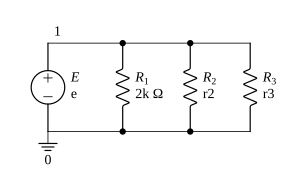

In [14]:
c5 = '''
e,1,0,e
r1,1,0,2'k
r2,1,0,r2
r3,1,0,r3
'''
draw(c5)

In [15]:
r5 = dc(c5, equations=["i_r1 = 8'm", "i_r2 = 10'm", "i_r3 = 2'm"], unknowns=['e', 'r2', 'r3'])
r5

Result(domain='dc')
  e = 16
  i_e = -1/50
  i_r1 = 1/125
  i_r2 = 1/100
  i_r3 = 1/500
  p_e = -8/25
  p_r1 = 16/125
  p_r2 = 4/25
  p_r3 = 4/125
  r2 = 1600
  r3 = 8000
  r_e = 800
  v_1 = 16
  v_e = 16
  v_r1 = 16
  v_r2 = 16
  v_r3 = 16

## 6. B11's Example 7.12 (Expert)

Design the voltage-divider supply: find R1, R2 and R3, then check the powers to decide whether 2 W resistors can be used. Five significant digits, so r1 reads 1333.3 as the chapter prints it rather than the exact 4000/3.

![The circuit of B11's Example 7.12 (Expert)](https://learn.symbulator.com/assets/practice/b11s-example-7-12-expert-3.jpg)

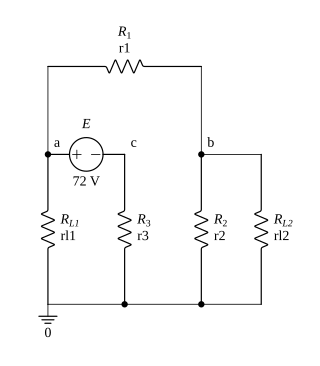

In [16]:
c6 = '''
e,a,c,72
r1,a,b,r1
r2,b,0,r2
r3,0,c,r3
rl1,a,0,rl1
rl2,b,0,rl2
'''
draw(c6)

In [17]:
r6 = dc(c6, equations=["i_rl1 = 20'm", 'v_rl1 = 60', "i_rl2 = 10'm", 'v_rl2 = 20', "-i_e = 50'm"], unknowns=['r1', 'r2', 'r3', 'rl1', 'rl2'])
r6.rounded(5)

Result(domain='dc')
  i_e = -0.050000
  i_r1 = 0.030000
  i_r2 = 0.020000
  i_r3 = 0.050000
  i_rl1 = 0.020000
  i_rl2 = 0.010000
  p_e = -3.6000
  p_r1 = 1.2000
  p_r2 = 0.40000
  p_r3 = 0.60000
  p_rl1 = 1.2000
  p_rl2 = 0.20000
  r1 = 1333.3
  r2 = 1000
  r3 = 240
  r_e = 1440
  rl1 = 3000
  rl2 = 2000
  v_a = 60
  v_b = 20
  v_c = -12
  v_e = 72
  v_r1 = 40
  v_r2 = 20
  v_r3 = 12
  v_rl1 = 60
  v_rl2 = 20